# Modelado de la TRM mensual: ARIMA y GARCH

Segunda etapa del análisis de la Tasa Representativa del Mercado (TRM). En el notebook 01 se estableció que la serie en nivel no es estacionaria y que su primera diferencia logarítmica sí satisface las condiciones de estacionariedad débil. A partir de esto, en este notebook se construye la serie del promedio mensual y se recorren las etapas de identificación, estimación y diagnóstico de la metodología Box-Jenkins, incorporando los modelos ARIMA y SARIMA para la media y un modelo GARCH para la varianza. El pronóstico, cuarta etapa de la metodología, se evalúa en el notebook 03.

| Notebook | Etapa |
|---|---|
| 01 · Exploración de la serie diaria | Calidad, patrones periódicos, atípicos, estacionariedad y ACF/PACF |
| **02 · Modelado mensual** | Identificación, estimación, diagnóstico y volatilidad (ARIMA + GARCH) |
| 03 · Pronóstico | Evaluación frente a la caminata aleatoria y pronóstico a 12 meses |

**Fuente de datos:** Banco de la República (2026), Portal de Estadísticas Económicas. Serie diaria de la TRM.

---
## Preparación del entorno

La estimación de los modelos ARIMA y SARIMA se realiza con statsmodels (Seabold & Perktold, 2010) y la de los modelos GARCH con la librería arch (Sheppard, 2025). La construcción de la serie mensual y el modelo final se encuentran en el paquete `trm` del repositorio, de modo que el notebook 03 y el tablero del proyecto utilizan exactamente la misma especificación.

In [ ]:
# En Google Colab el paquete del proyecto se instala desde GitHub; en el entorno local ya queda disponible con uv sync
import importlib.util
from IPython import get_ipython

if importlib.util.find_spec("trm") is None:
    get_ipython().run_line_magic("pip", "install -q git+https://github.com/Juanhv24/Time-Series-Colombia.git")

In [ ]:
import warnings

# Manejo de datos
import itertools
import numpy as np
import pandas as pd
from scipy import stats

# Visualización
import matplotlib.pyplot as plt

# Series de tiempo
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.stats.stattools import jarque_bera

# Paquete del proyecto
from trm import datos, modelo, pruebas
from trm.graficos import estilo, guardar, AZUL, ROJO, VERDE

estilo()
# statsmodels registra sus propios filtros al importarse, por lo que los avisos se silencian después de las importaciones
warnings.filterwarnings("ignore")

---
# Ciclo de trabajo

La metodología Box-Jenkins construye el modelo a partir de la propia estructura de dependencia de los datos, recorriendo sus etapas de forma iterativa (Box et al., 2015):

1. **Identificación:** se determina el orden de integración y, a partir de la lectura de la ACF y la PACF, se proponen modelos tentativos.
2. **Estimación:** se ajustan los parámetros de los candidatos y se evalúa su significancia.
3. **Diagnóstico:** se comprueba que los residuos se comporten como ruido blanco.
4. **Pronóstico:** se evalúa en el notebook 03.

El criterio que se aplica de forma transversal es el principio de parsimonia, según el cual entre modelos con desempeño comparable es preferible aquel que emplea menos parámetros (Box et al., 2015), y como se verá en la sección 3, este principio resulta determinante, ya que los criterios de información por sí solos no permiten resolver la elección.

---
# 1. Serie de trabajo

## 1.1 Construcción del promedio mensual

La TRM se calcula como el promedio ponderado de las operaciones de compra y venta de dólares de cada jornada (Banco de la República, 2018), y la serie que se modela corresponde a su promedio mensual. Antes de calcularlo se verifica que cada mes cuente con la totalidad de sus días, ya que un promedio construido con pocos días no es comparable con el de un mes completo.

In [ ]:
serie = datos.cargar_trm()
cobertura = datos.cobertura_mensual(serie)
print("Meses incompletos")
print(cobertura.loc[~cobertura["completo"], ["días con dato", "días del mes"]].to_string())

# Log-retorno de diciembre de 1991 si se conserva el promedio de noviembre
promedio_todos = datos.serie_mensual(serie, solo_completos=False)
y_todos = datos.log_retorno(promedio_todos)
print(f"\nLog-retorno de diciembre de 1991 frente al promedio de 4 días de noviembre: {y_todos.iloc[0]:.2f}")
print(f"Meses de la serie con un log-retorno de mayor magnitud: {(y_todos.abs() > abs(y_todos.iloc[0])).sum()}")

Meses incompletos
            días con dato  días del mes
fecha                                  
1991-11-01              4            30
2026-08-01             28            31

Log-retorno de diciembre de 1991 frente al promedio de 4 días de noviembre: -9.64
Meses de la serie con un log-retorno de mayor magnitud: 6


Período: 1991-12 a 2026-07 | meses: 416
Observaciones del log-retorno mensual: 415
Media: 0.3966 | Desviación estándar: 2.8997


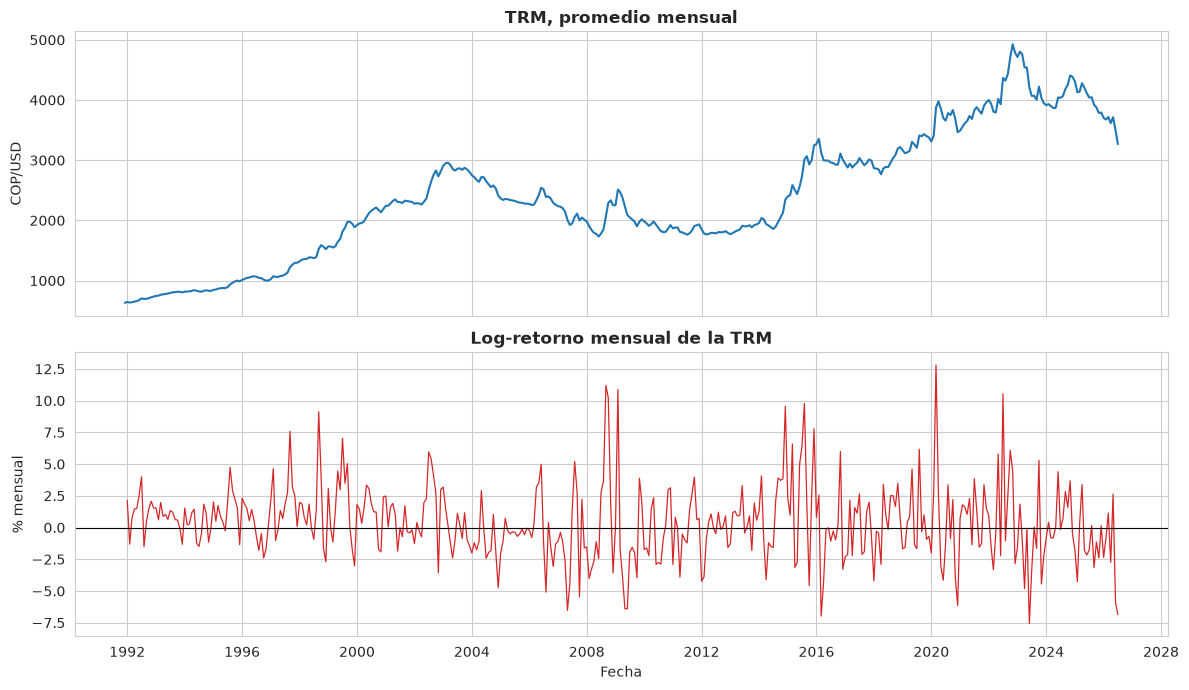

In [ ]:
trm_mensual = datos.serie_mensual(serie)      # solo meses completos
X = datos.log_nivel(trm_mensual)              # X_t = 100·log(TRM mensual)
y = X.diff().dropna()                         # log-retorno mensual, en porcentaje

print(f"Período: {X.index.min():%Y-%m} a {X.index.max():%Y-%m} | meses: {len(X)}")
print(f"Observaciones del log-retorno mensual: {len(y)}")
print(f"Media: {y.mean():.4f} | Desviación estándar: {y.std():.4f}")

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(trm_mensual.index, trm_mensual.values, color=AZUL)
axes[0].set_title("TRM, promedio mensual")
axes[0].set_ylabel("COP/USD")
axes[1].plot(y.index, y.values, color=ROJO, linewidth=0.9)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Log-retorno mensual de la TRM")
axes[1].set_ylabel("% mensual")
axes[1].set_xlabel("Fecha")
plt.tight_layout()
guardar(fig, "10_trm_mensual.png")
plt.show()

**Interpretación:** A partir de la salida podemos observar que los dos meses de los extremos de la serie se encuentran incompletos, ya que por un lado noviembre de 1991 cuenta con 4 de sus 30 días, mientras que por otro lado agosto de 2026 cuenta con 28 de sus 31 días. En el caso de noviembre, el promedio de solo 4 días genera un log-retorno de -9.64 % en diciembre de 1991, valor que se ubica entre los siete de mayor magnitud de toda la serie a pesar de que no corresponde a un movimiento del mercado, sino a la forma en que se construyó el promedio. Teniendo en cuenta lo anterior, se optó por excluir ambos meses, por lo que la serie de trabajo queda comprendida entre diciembre de 1991 y julio de 2026, con 416 meses y 415 log-retornos, y el efecto de esta decisión sobre el modelo se cuantifica en la sección 3.4.

Por otro lado, en la gráfica el panel superior muestra que el promedio mensual conserva la tendencia creciente de largo plazo identificada en la serie diaria, aunque con una trayectoria más suavizada, mientras que en el panel inferior el log-retorno mensual oscila en torno a cero durante todo el período, con episodios de mayor amplitud que coinciden con los tramos de depreciación acelerada descritos en el notebook 01.

## 1.2 ¿Por qué la frecuencia mensual?

En el notebook 01 el análisis se desarrolló sobre el log-retorno diario de la TRM, mientras que para el modelado se trabaja sobre el **log-retorno del promedio mensual**, definido como

$$y_t = \Delta\log(\overline{TRM}_t) \times 100$$

donde $\overline{TRM}_t$ corresponde al promedio de la TRM durante el mes $t$. Esta decisión se adoptó por dos consideraciones. La primera surge de la banda de confianza con la que se juzga la significancia de los coeficientes de la ACF, que se calcula como $\pm 1.96/\sqrt{n}$ bajo la hipótesis nula de ruido blanco (Box et al., 2015), de modo que su amplitud depende directamente del tamaño muestral y las dos frecuencias producen bandas muy distintas. La segunda consideración se relaciona con la regla de publicación identificada en el notebook 01, según la cual sábados, domingos y festivos adoptan la TRM vigente del día hábil inmediatamente siguiente (Banco de la República, 2018), por lo que la serie diaria incorpora retornos nulos que no corresponden a jornadas de negociación, mientras que el promedio mensual agrega conjuntamente los días hábiles y los heredados dentro de cada mes, de tal forma que los valores repetidos no aparecen como observaciones independientes de la serie modelada.

Para documentar la primera consideración con evidencia se contrastan ambas frecuencias, y como referencia común se ajusta sobre cada una el mismo modelo MA(1), cuya elección se justifica en las secciones 2 y 3.

In [ ]:
y_diario = datos.log_retorno(serie).reset_index(drop=True)

comparacion_frec = []
for nombre, s in [("Diaria", y_diario), ("Mensual", y.reset_index(drop=True))]:
    a_s = acf(s, nlags=24)
    umbral = pruebas.banda(len(s))
    ajuste = ARIMA(s, order=(0, 0, 1)).fit()
    lb = acorr_ljungbox(ajuste.resid, lags=[12], model_df=1, return_df=True)
    comparacion_frec.append({
        "Frecuencia": nombre,
        "n": len(s),
        "Umbral": round(umbral, 4),
        "ACF(1)": round(a_s[1], 4),
        "Signif. de 24": sum(abs(a_s[k]) > umbral for k in range(1, 25)),
        "Mayor ACF tras rezago 1": round(max(abs(a_s[k]) for k in range(2, 25)), 4),
        "MA(1) theta": round(ajuste.params["ma.L1"], 4),
        "LB(12) p-valor": round(lb["lb_pvalue"].iloc[0], 4),
    })

print(pd.DataFrame(comparacion_frec).to_string(index=False))

Frecuencia     n  Umbral  ACF(1)  Signif. de 24  Mayor ACF tras rezago 1  MA(1) theta  LB(12) p-valor
    Diaria 12693  0.0174  0.1330             10                   0.0433       0.1398          0.0046
   Mensual   415  0.0962  0.3087              1                   0.0929       0.3277          0.3558


**Interpretación:** Al realizar el contraste se logran observar tres diferencias. La primera se relaciona con los rezagos marcados como significativos, ya que en la serie diaria el umbral es de ±0.0174 frente a ±0.0962 en la mensual, y el número de rezagos que lo superan pasa de 10 a 1. Ahora bien, la mayor autocorrelación posterior al primer rezago es de apenas 0.0433 en la serie diaria, magnitud cuyo cuadrado representa menos del 0.2 % de la varianza, lo que quiere decir que esos diez rezagos son estadísticamente significativos, pero de tamaño despreciable, lo cual dificulta reconocer el patrón de corte que se requiere para proponer los órdenes del modelo.

La segunda diferencia se observa en el diagnóstico, ya que la prueba de Ljung-Box rechaza la independencia de los residuos sobre la serie diaria, con un p-valor de 0.0046, y no la rechaza sobre la mensual, con un p-valor de 0.3558, aun tratándose del mismo tipo de modelo. Teniendo en cuenta que la prueba acumula los cuadrados de las autocorrelaciones residuales ponderados por el tamaño muestral (Ljung & Box, 1978), con 12 693 observaciones autocorrelaciones residuales inferiores a 0.03 son suficientes para producir el rechazo.

Para finalizar, el coeficiente de media móvil aumenta de 0.1398 a 0.3277 al pasar a la frecuencia mensual, resultado cuya explicación se desarrolla en la sección 2.2, ya que depende de la forma en que se construye la TRM.

---
# 2. Identificación

## 2.1 ¿Qué tipo de memoria tiene la serie?

La etapa de identificación consiste en reconocer cómo persiste el pasado dentro de la serie, para lo cual se contemplan tres familias de modelos que se distinguen precisamente por el tipo de memoria que suponen.

| Familia | Qué recuerda la serie | Firma en la ACF | Firma en la PACF |
|---|---|---|---|
| **AR(p)** | Sus propios valores pasados | Decae gradualmente | Se corta en el rezago $p$ |
| **MA(q)** | Los choques pasados | Se corta en el rezago $q$ | Decae gradualmente |
| **ARMA(p, q)** | Valores y choques a la vez | Decae gradualmente | Decae gradualmente |

Estas firmas son consecuencias directas de la forma de cada modelo y constituyen la herramienta central de la etapa (Box et al., 2015). Sin embargo, antes de leer las funciones de autocorrelación es conveniente saber qué esperar, teniendo en cuenta cómo se construye la TRM.

## 2.2 Qué cabe esperar dado cómo se construye la TRM

En el notebook 01 se llegó a la conclusión de que el log-retorno diario se aproxima a un proceso de ruido blanco, resultado consistente con la hipótesis de eficiencia del mercado, según la cual el precio de un activo en un mercado eficiente incorpora toda la información disponible y sus variaciones no son predecibles a partir del pasado (Fama, 1970). Teniendo en cuenta este supuesto, no debería existir estructura alguna que modelar. Sin embargo, la TRM no es un precio de cierre, sino el promedio ponderado de las operaciones de compra y venta de dólares registradas durante la jornada (Banco de la República, 2018), y además la serie que se modela añade una segunda capa de promediado al calcular la media mensual de esos valores diarios.

A partir de esta distinción se deriva una consecuencia concreta, ya que Working (1960) demostró que la agregación temporal de una caminata aleatoria induce en las primeras diferencias una correlación serial positiva que no está presente en la serie subyacente, y que dicho efecto se manifiesta como una estructura de media móvil de primer orden, con una autocorrelación teórica cercana a 0.25. El mecanismo es intuitivo si se piensa en términos de memoria, ya que dos promedios consecutivos no comparten valores, pero sí comparten los choques que ocurren dentro del período que ambos abarcan, lo que quiere decir que la serie no arrastra su nivel anterior sino las perturbaciones anteriores, que es exactamente lo que describe un modelo MA. Este mismo mecanismo explica que el coeficiente del MA(1) de la sección 1.2 sea mayor en la serie mensual, ya que el promedio de un mes constituye una agregación más prolongada que el de una jornada.

En conjunto, lo anterior permite plantear una hipótesis antes de mirar los datos, la cual es que, si la estructura que aparezca proviene del método de cálculo y no del comportamiento del mercado, la ACF debería cortarse en el primer rezago y el coeficiente debería ubicarse en el orden de 0.25 y con signo positivo, hipótesis que se contrasta en las secciones siguientes.

## 2.3 Orden de integración

Los modelos ARIMA incorporan la diferenciación dentro de su especificación, por lo que el primer paso de la identificación consiste en determinar el orden $d$ que vuelve estacionaria a la serie (Box et al., 2015). Para esto se aplican de forma conjunta las pruebas ADF y KPSS, cuyas hipótesis nulas son opuestas (Dickey & Fuller, 1979; Kwiatkowski et al., 1992), sobre el log-nivel $X_t = 100\log(\overline{TRM}_t)$ y sobre su primera diferencia, que es el log-retorno mensual $y_t$.

In [ ]:
print(pd.DataFrame([
    pruebas.estacionariedad(X, "Log-nivel (d = 0)"),
    pruebas.estacionariedad(y, "Primera diferencia (d = 1)"),
]).to_string(index=False))

                     Serie  ADF estadístico ADF p-valor  KPSS estadístico KPSS p-valor      Conclusión
         Log-nivel (d = 0)          -2.5661      0.1002            2.4142       < 0.01 no estacionaria
Primera diferencia (d = 1)         -12.6941      0.0000            0.4158       0.0703    estacionaria


**Interpretación:** Los resultados muestran que en el log-nivel la prueba ADF no rechaza la raíz unitaria, con un p-valor de 0.1002, y la prueba KPSS rechaza la estacionariedad, con un p-valor inferior a 0.01, mientras que en la primera diferencia ambas coinciden en clasificar la serie como estacionaria, con p-valores de 0.0000 y 0.0703 respectivamente. Por ende, el orden de integración es $d = 1$, lo que tiene una consecuencia directa sobre la especificación, ya que modelar el log-retorno $y_t = X_t - X_{t-1}$ con un ARMA equivale a modelar el log-nivel con un ARIMA$(p, 1, q)$ (Box et al., 2015). En este notebook se estima directamente el ARIMA sobre $X_t$, lo cual resulta necesario para obtener el pronóstico en pesos por dólar en el notebook 03.

## 2.4 Rezagos simples y estacionales en la ACF y la PACF

Debido a que se trabaja con el promedio mensual, un patrón anual debería manifestarse en los rezagos múltiplos de 12, por lo que el análisis se extiende a 48 rezagos con el fin de evaluar la parte estacional en cuatro ciclos anuales, marcados con líneas punteadas en la gráfica. Además, dado que la lectura visual de las bandas puede resultar ambigua cuando los coeficientes son pequeños, la gráfica se acompaña con los valores numéricos y el umbral de significancia $\pm 1.96/\sqrt{n}$ (Box et al., 2015).

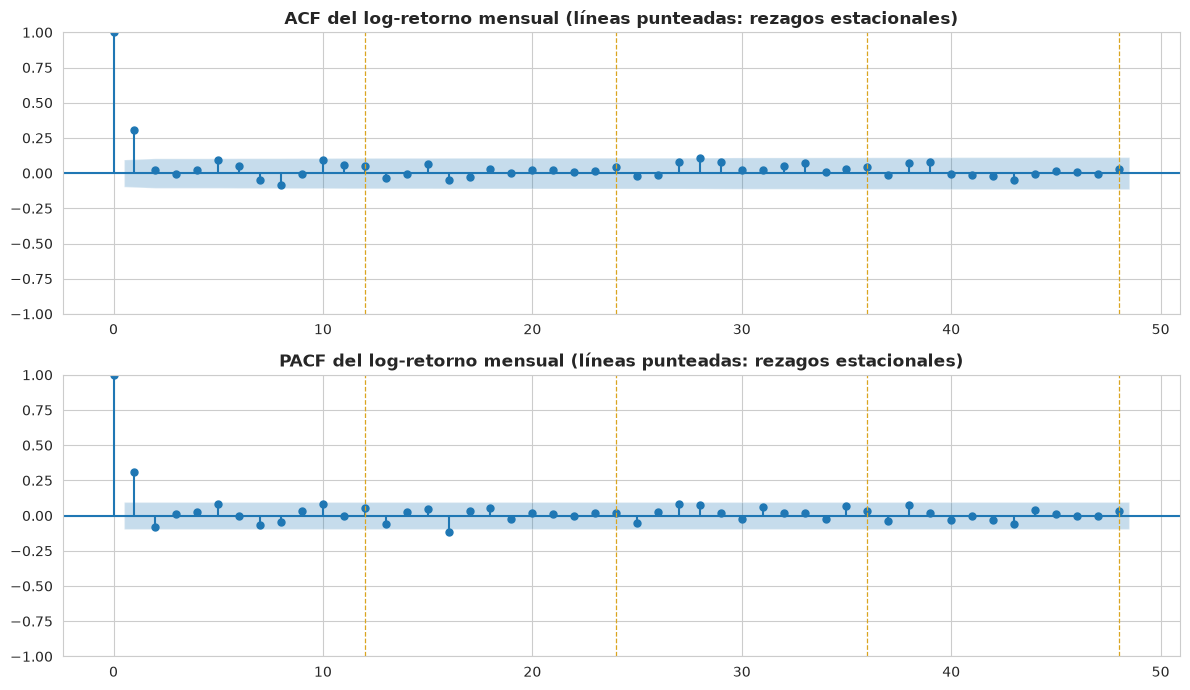

n = 415 | umbral de significancia = ±0.0962

 rezago     ACF    PACF ACF signif. PACF signif.
      1  0.3087  0.3094          Sí           Sí
      2  0.0201 -0.0835          No           No
      3 -0.0080  0.0123          No           No
      4  0.0239  0.0277          No           No
      5  0.0929  0.0854          No           No
      6  0.0505 -0.0049          No           No
      7 -0.0485 -0.0661          No           No
      8 -0.0817 -0.0484          No           No
      9 -0.0073  0.0335          No           No
     10  0.0916  0.0829          No           No
     11  0.0547 -0.0048          No           No
     12  0.0536  0.0591          No           No
     24  0.0431  0.0234          No           No
     36  0.0434  0.0350          No           No
     48  0.0323  0.0381          No           No


In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7))
plot_acf(y, lags=48, ax=axes[0])
plot_pacf(y, lags=48, ax=axes[1])
for ax, nombre in zip(axes, ["ACF", "PACF"]):
    for k in (12, 24, 36, 48):
        ax.axvline(k, color="goldenrod", linestyle="--", linewidth=0.9)
    ax.set_title(f"{nombre} del log-retorno mensual (líneas punteadas: rezagos estacionales)")
plt.tight_layout()
guardar(fig, "11_acf_pacf_mensual.png")
plt.show()

tabla_id = pruebas.tabla_autocorrelacion(y, list(range(1, 13)) + [24, 36, 48])
print(f"n = {len(y)} | umbral de significancia = ±{pruebas.banda(len(y)):.4f}\n")
print(tabla_id.to_string(index=False))

In [ ]:
a, p = acf(y, nlags=48), pacf(y, nlags=48)
umbral = pruebas.banda(len(y))
print(f"Rezagos fuera del umbral (de 48) -> ACF: {[k for k in range(1, 49) if abs(a[k]) > umbral]} "
      f"| PACF: {[k for k in range(1, 49) if abs(p[k]) > umbral]}")
print(f"Rezagos esperados fuera del umbral por azar, al 5 %: {0.05 * 48:.1f} por función")

Rezagos fuera del umbral (de 48) -> ACF: [1, 28] | PACF: [1, 16]
Rezagos esperados fuera del umbral por azar, al 5 %: 2.4 por función


**Interpretación:** A partir de lo que se observa, tanto la ACF como la PACF presentan un único coeficiente dominante en el primer rezago, con valores de 0.3087 y 0.3094 respectivamente, mientras que la totalidad de los rezagos restantes hasta el 12 caen dentro del umbral. Si contrastamos estos resultados con la hipótesis de la sección 2.2, el valor de 0.3087 es del mismo signo y del mismo orden de magnitud que el 0.25 que se anticipó a partir del efecto de agregación temporal (Working, 1960), y la ACF se corta después del primer rezago tal como se había previsto, por ende, la predicción resulta compatible con lo observado.

A pesar de lo anterior, la evidencia gráfica no es suficiente para cerrar la elección, ya que el corte se produce simultáneamente en ambas funciones, y según la tabla de la sección 2.1 un corte en la ACF apunta a un modelo MA, mientras que un corte en la PACF apunta a un modelo AR, de tal modo que la firma observada es compatible con las dos especificaciones de orden uno. Esta ambigüedad es esperable cuando el coeficiente es de magnitud moderada, lo que obliga a complementar la lectura gráfica con criterios formales en la etapa de estimación.

Con lo que respecta a los rezagos estacionales 12, 24, 36 y 48, ningún coeficiente supera el umbral de ±0.0962, siendo el mayor el de la PACF en el rezago 12, con 0.0591. Por otro lado, fuera del primer rezago aparecen dos valores aislados por encima del umbral, el rezago 28 en la ACF y el 16 en la PACF, sin embargo, con 48 rezagos evaluados al 5 % se esperan 2.4 por azar en cada función, y ninguno de los dos corresponde a un múltiplo de 12, por lo que no constituyen evidencia de un patrón estacional.

## 2.5 ¿Requiere la serie una diferenciación estacional?

Dado que la ACF no muestra picos en los rezagos estacionales, se evalúa de manera formal si es necesario aplicar una diferenciación estacional $D = 1$. Para esto se contrastan dos elementos, por un lado la prueba de Kruskal-Wallis, que compara la distribución del log-retorno entre los doce meses del año sin suponer normalidad (Kruskal & Wallis, 1952), y por otro lado el efecto que tendría imponer $D = 1$ sobre la serie.

In [ ]:
# Efecto calendario: distribución del log-retorno por mes del año
grupos = [y[y.index.month == mes] for mes in range(1, 13)]
kw = stats.kruskal(*grupos)
print(f"Kruskal-Wallis por mes: H = {kw.statistic:.2f} | p-valor = {kw.pvalue:.4f}")

# Consecuencia de imponer una diferencia estacional (D = 1) sobre esta serie
y_D = X.diff().diff(12).dropna()
print(f"ACF en el rezago 12 con d = 1 y D = 1: {acf(y_D, nlags=12)[12]:.4f}")

modelo_D = SARIMAX(X, order=(0, 1, 1), seasonal_order=(0, 1, 1, 12)).fit(disp=False)
print(f"Coeficiente MA estacional estimado con D = 1: {modelo_D.params['ma.S.L12']:.4f}")

Kruskal-Wallis por mes: H = 16.54 | p-valor = 0.1221
ACF en el rezago 12 con d = 1 y D = 1: -0.4831


Coeficiente MA estacional estimado con D = 1: -0.9128


**Interpretación:** La prueba de Kruskal-Wallis no rechaza la igualdad de las distribuciones entre meses, con un p-valor de 0.1221, lo que quiere decir que no existe evidencia de un efecto calendario en el log-retorno mensual. Por otro lado, al imponer $D = 1$ la ACF en el rezago 12 toma un valor de -0.4831, cercano al -0.5 que se obtiene por construcción al diferenciar estacionalmente una serie sin componente estacional, ya que la covarianza entre $\varepsilon_t - \varepsilon_{t-12}$ y $\varepsilon_{t-12} - \varepsilon_{t-24}$ es $-\sigma^2$, mientras que la varianza de cada término es $2\sigma^2$. Además, el coeficiente MA estacional estimado es de -0.9128, próximo a -1, siendo este el síntoma característico de una sobrediferenciación, que introduce una raíz unitaria en la parte de media móvil (Plosser & Schwert, 1977). Teniendo en cuenta lo anterior, se fija $D = 0$.

## 2.6 Modelos candidatos y su expresión matemática

Cada familia de la sección 2.1 tiene una forma general (Box et al., 2015). Los modelos **AR(p)** expresan el valor actual como una combinación lineal de sus valores pasados más un término de error, los modelos **MA(q)** lo expresan como una combinación lineal del error actual y de los errores anteriores, y los modelos **ARMA(p, q)** combinan ambos tipos de memoria:

$$Y_t = c + \phi_1 Y_{t-1} + \dots + \phi_p Y_{t-p} + \varepsilon_t \qquad\qquad Y_t = \mu + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \dots + \theta_q \varepsilon_{t-q}$$

$$Y_t = c + \phi_1 Y_{t-1} + \dots + \phi_p Y_{t-p} + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \dots + \theta_q \varepsilon_{t-q}$$

donde $\varepsilon_t$ es ruido blanco. La parte AR es estacionaria si las raíces de su polinomio se encuentran fuera del círculo unitario, lo que en el caso de orden uno se reduce a $|\phi_1| < 1$, y la parte MA es invertible bajo la condición equivalente, $|\theta_1| < 1$ en el caso de orden uno, necesaria para que la representación sea única.

Con lo que respecta a la selección de candidatos, esta se acota a lo observado en la ACF y la PACF. Por un lado, en la parte regular el único rezago significativo es el primero, por lo que los órdenes se limitan a $p, q \in \{0, 1\}$, mientras que en la parte estacional no se observan coeficientes significativos, sin embargo, se incluyen los órdenes $P, Q \in \{0, 1\}$ con el fin de verificar de manera formal que el componente estacional no aporta a la especificación. Además, la diferenciación se mantiene en $d = 1$ y $D = 0$ por lo obtenido en las secciones 2.3 y 2.5, de forma que la grilla contiene 16 especificaciones, entre ellas la caminata aleatoria con deriva, ARIMA(0,1,0). Todas corresponden a la forma general SARIMA$(p,d,q)(P,D,Q)_s$ (Box et al., 2015):

$$\phi(L)\,\Phi(L^s)\,(1-L)^d\,(1-L^s)^D X_t = c + \theta(L)\,\Theta(L^s)\,\varepsilon_t$$

donde $L$ es el operador de rezago, $\phi(L)$ y $\theta(L)$ son los polinomios autorregresivo y de media móvil de la parte regular, $\Phi(L^s)$ y $\Theta(L^s)$ los de la parte estacional con $s = 12$ y $c$ es la constante. Cuando $P = Q = D = 0$ la expresión se reduce a un ARIMA$(p,d,q)$.

---
# 3. Estimación

## 3.1 Grilla de modelos candidatos

Cada especificación se compara mediante la log-verosimilitud, que mide el ajuste, y los criterios de información de Akaike (1974) y de Schwarz (1978), que penalizan el número de parámetros, siendo el de Schwarz (BIC) el más severo. A partir de esto se obtiene una tabla ordenada por BIC que reporta además los coeficientes que no alcanzan significancia al 5 %.

In [ ]:
filas = []
for p_ord, q_ord, P, Q in itertools.product((0, 1), repeat=4):
    ajuste = SARIMAX(X, order=(p_ord, 1, q_ord), seasonal_order=(P, 0, Q, 12), trend="c").fit(disp=False)
    coef = ajuste.pvalues.drop("sigma2")
    nombre = (f"ARIMA({p_ord},1,{q_ord})" if P == Q == 0
              else f"SARIMA({p_ord},1,{q_ord})({P},0,{Q})12")
    filas.append({
        "Modelo": nombre,
        "k": len(ajuste.params),
        "Log-verosimilitud": round(ajuste.llf, 2),
        "AIC": round(ajuste.aic, 2),
        "BIC": round(ajuste.bic, 2),
        "Coef. no significativos": ", ".join(coef.index[coef >= 0.05]) or "ninguno",
    })

grilla = pd.DataFrame(filas).sort_values("BIC").reset_index(drop=True)
print("k: número de parámetros estimados, incluida la varianza del error\n")
print(grilla.to_string(index=False))

k: número de parámetros estimados, incluida la varianza del error

                Modelo  k  Log-verosimilitud     AIC     BIC    Coef. no significativos
          ARIMA(0,1,1)  3           -1007.93 2021.87 2033.95                    ninguno
          ARIMA(1,1,0)  3           -1009.09 2024.17 2036.26                  intercept
SARIMA(0,1,1)(1,0,0)12  4           -1007.01 2022.02 2038.13        intercept, ar.S.L12
SARIMA(0,1,1)(0,0,1)12  4           -1007.09 2022.18 2038.29        intercept, ma.S.L12
          ARIMA(1,1,1)  4           -1007.74 2023.48 2039.59           intercept, ar.L1
SARIMA(1,1,0)(1,0,0)12  4           -1008.36 2024.71 2040.83        intercept, ar.S.L12
SARIMA(0,1,1)(1,0,1)12  5           -1005.36 2020.71 2040.85                  intercept
SARIMA(1,1,0)(0,0,1)12  4           -1008.42 2024.85 2040.96        intercept, ma.S.L12
SARIMA(1,1,0)(1,0,1)12  5           -1006.69 2023.38 2043.52                  intercept
SARIMA(1,1,1)(1,0,0)12  5           -1006.83 2023.67 

**Interpretación:** A partir de los resultados observados en la tabla se puede determinar que el modelo que encabeza la grilla por BIC es un ARIMA(0,1,1), con un valor de 2033.95, y que junto con la caminata aleatoria son los únicos modelos en los que todos los coeficientes resultan significativos. Por otro lado, el menor AIC corresponde al SARIMA(0,1,1)(1,0,1)12, con 2020.71, sin embargo, su BIC de 2040.85 lo ubica en el séptimo lugar, lo cual indica que la mejora en el ajuste no compensa los parámetros adicionales. Con lo que respecta a la caminata aleatoria, esta presenta el menor ajuste de los modelos sin componente estacional, con una log-verosimilitud de -1030.17 frente a -1007.93 del ARIMA(0,1,1), lo que confirma que el término de media móvil captura una estructura presente en la muestra. Finalmente, el ARIMA(1,1,1), que combina las dos lecturas posibles de la sección 2.4, pierde la significancia de su término autorregresivo, síntoma de una especificación sobreparametrizada en la que un término AR y uno MA compiten por explicar la misma estructura de primer orden.

## 3.2 Verificación con una grilla ampliada

Como verificación complementaria se amplía la parte regular a $p, q \in \{0, 1, 2, 3\}$ sin componente estacional, con el fin de comprobar que la selección no depende de haber acotado los órdenes a partir de la lectura de la ACF y la PACF. Para interpretar las diferencias se acude a la escala convencional del $\Delta AIC$, según la cual los modelos situados dentro de 2 unidades del mejor cuentan con apoyo sustancial de los datos, y solo por encima de 10 unidades el apoyo se considera inexistente (Burnham & Anderson, 2002).

In [ ]:
ampliada = []
for p_ord in range(4):
    for q_ord in range(4):
        if p_ord == q_ord == 0:
            continue
        ajuste = SARIMAX(X, order=(p_ord, 1, q_ord), trend="c").fit(disp=False, maxiter=500)
        ampliada.append({"Modelo": f"ARIMA({p_ord},1,{q_ord})", "k": len(ajuste.params),
                         "AIC": round(ajuste.aic, 2), "BIC": round(ajuste.bic, 2)})

ampliada = pd.DataFrame(ampliada)
ampliada["delta_AIC"] = (ampliada["AIC"] - ampliada["AIC"].min()).round(2)
print("Cinco mejores modelos según AIC:")
print(ampliada.sort_values("AIC").head().to_string(index=False))
print("\nCinco mejores modelos según BIC:")
print(ampliada.sort_values("BIC").head().to_string(index=False))

Cinco mejores modelos según AIC:
      Modelo  k     AIC     BIC  delta_AIC
ARIMA(0,1,1)  3 2021.87 2033.95       0.00
ARIMA(2,1,3)  7 2023.05 2051.25       1.18
ARIMA(2,1,0)  4 2023.42 2039.53       1.55
ARIMA(0,1,2)  4 2023.45 2039.56       1.58
ARIMA(1,1,1)  4 2023.48 2039.59       1.61

Cinco mejores modelos según BIC:
      Modelo  k     AIC     BIC  delta_AIC
ARIMA(0,1,1)  3 2021.87 2033.95       0.00
ARIMA(1,1,0)  3 2024.17 2036.26       2.30
ARIMA(2,1,0)  4 2023.42 2039.53       1.55
ARIMA(0,1,2)  4 2023.45 2039.56       1.58
ARIMA(1,1,1)  4 2023.48 2039.59       1.61


**Interpretación:** En la grilla ampliada el ARIMA(0,1,1) encabeza ambos ordenamientos, con el menor AIC y el menor BIC entre los 15 modelos evaluados. A pesar de esto, el segundo lugar por AIC corresponde a un ARIMA(2,1,3), que se ubica a solo 1.18 unidades, de modo que según la escala de Burnham y Anderson (2002) ambos modelos están igualmente respaldados por este criterio. Teniendo en cuenta lo anterior, la elección no se puede resolver únicamente por AIC y debe apoyarse en la parsimonia, criterio que favorece al ARIMA(0,1,1), ya que emplea un solo término de media móvil frente a los cinco términos del ARIMA(2,1,3) (Box et al., 2015), además de que el ordenamiento por BIC, en el que el ARIMA(2,1,3) ni siquiera aparece entre los cinco mejores, respalda esa conclusión.

## 3.3 Pruebas de razón de verosimilitud

En cuanto a los modelos anidados, la diferencia en log-verosimilitud se evalúa mediante la prueba de razón de verosimilitud, cuyo estadístico $LR = 2(\ell_{general} - \ell_{restringido})$ sigue de forma asintótica una distribución chi-cuadrado con tantos grados de libertad como parámetros adicionales tenga el modelo general (Wilks, 1938). Con lo que respecta al ARIMA(0,1,1), se contrastan tres elementos: los términos estacionales, un término AR regular y la constante.

In [ ]:
arima_011 = modelo.ajustar_media(X)
arima_011_sin_c = modelo.ajustar_media(X, constante=False)
arima_111 = SARIMAX(X, order=(1, 1, 1), trend="c").fit(disp=False)
sarima_101 = SARIMAX(X, order=(0, 1, 1), seasonal_order=(1, 0, 1, 12), trend="c").fit(disp=False)

print(pd.DataFrame([
    pruebas.razon_verosimilitud(arima_011, sarima_101, "AR y MA estacionales"),
    pruebas.razon_verosimilitud(arima_011, arima_111, "AR regular"),
    pruebas.razon_verosimilitud(arima_011_sin_c, arima_011, "Constante"),
]).to_string(index=False))

print("\nCoeficientes estacionales del SARIMA(0,1,1)(1,0,1)12:")
print(sarima_101.params[["ar.S.L12", "ma.S.L12"]].round(4).to_string())
print(f"\nSin constante -> AIC = {arima_011_sin_c.aic:.2f} | BIC = {arima_011_sin_c.bic:.2f}")
print(f"Con constante -> AIC = {arima_011.aic:.2f} | BIC = {arima_011.bic:.2f}")

           Contraste    LR  gl  p-valor
AR y MA estacionales 5.154   2   0.0760
          AR regular 0.389   1   0.5326
           Constante 4.817   1   0.0282

Coeficientes estacionales del SARIMA(0,1,1)(1,0,1)12:
ar.S.L12    0.8377
ma.S.L12   -0.7751

Sin constante -> AIC = 2024.68 | BIC = 2032.74
Con constante -> AIC = 2021.87 | BIC = 2033.95


**Interpretación:** Con lo que respecta a los términos estacionales, se evidencia que no resultan significativos en conjunto, con un p-valor de 0.0760, y tampoco lo es el término AR regular, con un p-valor de 0.5326. En el caso del SARIMA(0,1,1)(1,0,1)12, sus coeficientes estacionales de 0.8377 y -0.7751 son de magnitud similar, de tal forma que el factor $(1 - 0.8377L^{12})$ de la parte autorregresiva y el factor $(1 - 0.7751L^{12})$ de la parte de media móvil tienden a cancelarse, siendo esta una señal de redundancia de parámetros (Box et al., 2015) que explica por qué el menor AIC de la grilla no se traduce en una especificación útil.

Por otro lado, la constante sí resulta significativa, con un p-valor de 0.0282, y su inclusión reduce el AIC de 2024.68 a 2021.87, mientras que el BIC aumenta ligeramente de 2032.74 a 2033.95, debido a la mayor penalización que este criterio aplica por parámetro. Teniendo en cuenta que tanto la prueba de razón de verosimilitud como el AIC favorecen la constante, esta se conserva en el modelo.

## 3.4 Modelo seleccionado

In [ ]:
modelo_media = arima_011
print(modelo_media.summary().tables[1])
print(f"\nLog-verosimilitud = {modelo_media.llf:.2f} | AIC = {modelo_media.aic:.2f} | BIC = {modelo_media.bic:.2f}")

# Autocorrelación de primer orden implicada por el MA(1): theta / (1 + theta^2)
theta = modelo_media.params["ma.L1"]
print(f"ACF(1) implicada por el modelo: {theta / (1 + theta ** 2):.4f} | ACF(1) observada: {a[1]:.4f}")

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.3946      0.191      2.067      0.039       0.020       0.769
ma.L1          0.3277      0.036      8.981      0.000       0.256       0.399
sigma2         7.5335      0.379     19.891      0.000       6.791       8.276

Log-verosimilitud = -1007.93 | AIC = 2021.87 | BIC = 2033.95
ACF(1) implicada por el modelo: 0.2959 | ACF(1) observada: 0.3087


**Interpretación:** A partir de los resultados, el modelo seleccionado es un ARIMA(0,1,1) con constante, cuyos coeficientes resultan significativos al 5 %, con un término de media móvil de 0.3277 y una constante de 0.3946, que representa la depreciación promedio mensual del peso en el período analizado. Remplazando los valores estimados en la forma general de la sección 2.6 con $p = 0$, $d = 1$ y $q = 1$, se obtiene el modelo

$$(1 - L)X_t = 0.3946 + (1 + 0.3277L)\,\varepsilon_t$$

que de forma equivalente se expresa como

$$X_t = X_{t-1} + 0.3946 + \varepsilon_t + 0.3277\,\varepsilon_{t-1}, \qquad \hat{\sigma}^2 = 7.5335$$

donde $X_t = 100\log(\overline{TRM}_t)$. Dado que $y_t = X_t - X_{t-1}$, el modelo corresponde a un MA(1) sobre el log-retorno mensual, $y_t = 0.3946 + \varepsilon_t + 0.3277\,\varepsilon_{t-1}$, que es exactamente la familia que anticipaba la hipótesis de la sección 2.2. Además, la autocorrelación de primer orden que implica el modelo, $\theta/(1 + \theta^2)$ (Box et al., 2015), es de 0.2959, cercana tanto a la observada de 0.3087 como al 0.25 que predice el efecto de agregación temporal (Working, 1960), mientras que un coeficiente autorregresivo de magnitud similar no tendría una explicación equivalente en el mecanismo de construcción de la serie.

In [ ]:
# Sensibilidad a los meses incompletos: el mismo modelo estimado conservando noviembre de 1991 y agosto de 2026
sensibilidad = []
for nombre, serie_X in [("Todos los meses", datos.log_nivel(promedio_todos)), ("Meses completos", X)]:
    ajuste = modelo.ajustar_media(serie_X)
    sensibilidad.append({"Serie": nombre, "meses": len(serie_X),
                         "constante": round(ajuste.params["intercept"], 4),
                         "p-valor constante": round(ajuste.pvalues["intercept"], 4),
                         "theta": round(ajuste.params["ma.L1"], 4),
                         "sigma2": round(ajuste.params["sigma2"], 4)})
print(pd.DataFrame(sensibilidad).to_string(index=False))

          Serie  meses  constante  p-valor constante  theta  sigma2
Todos los meses    418     0.3498             0.0610 0.3212  7.8023
Meses completos    416     0.3946             0.0388 0.3277  7.5335


**Interpretación:** Al estimar el mismo modelo conservando los meses incompletos, la constante toma un valor de 0.3498 con un p-valor de 0.0610, de modo que no alcanza el umbral del 5 %, mientras que con los meses completos pasa a 0.3946 con un p-valor de 0.0388. Este cambio se relaciona con la exclusión de noviembre de 1991 y su log-retorno de -9.64 %, que al tratarse de un valor negativo de gran magnitud reduce la depreciación promedio estimada y aumenta la varianza del error, de 7.5335 a 7.8023. Por otro lado, el coeficiente de media móvil se mantiene prácticamente igual, con 0.3212 frente a 0.3277, lo que quiere decir que la revisión de la calidad de los datos no modifica la estructura de dependencia identificada, pero sí la conclusión sobre la deriva, que es precisamente el término que determina la tendencia del pronóstico en el notebook 03.

---
# 4. Diagnóstico

## 4.1 Residuos y autocorrelación

Si el modelo está bien especificado, sus residuos deben comportarse como ruido blanco, es decir, sin autocorrelación remanente y con media aproximadamente nula (Box et al., 2015). Para verificarlo se examinan la gráfica de los residuos y su ACF, y se aplica la prueba de Ljung-Box, que contrasta la hipótesis nula de independencia evaluando de forma conjunta las autocorrelaciones hasta un rezago dado, con los grados de libertad ajustados por el número de parámetros ARMA estimados, que en este caso corresponde a uno (Ljung & Box, 1978).

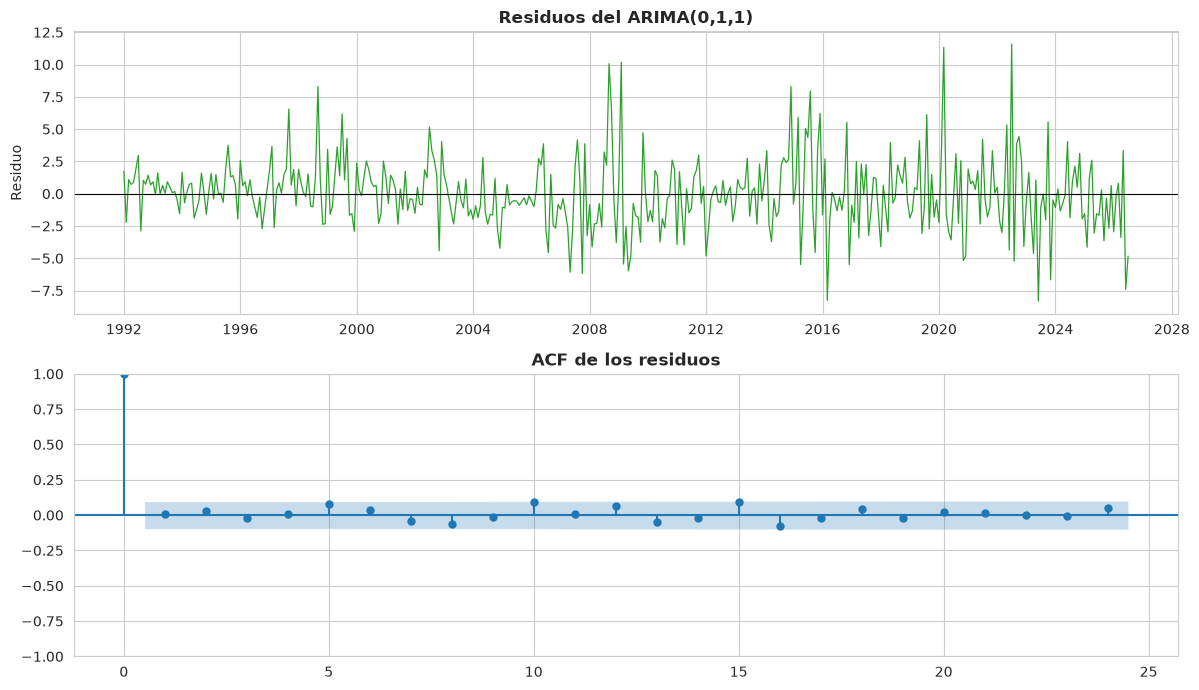

Media de los residuos: -0.0013
Rezagos con autocorrelación significativa: 0 de 24 | máxima en valor absoluto: 0.0955 (umbral ±0.0962)

Ljung-Box, H0: residuos independientes (grados de libertad ajustados por el MA(1))
    lb_stat  lb_pvalue       decisión
6    3.8047     0.5779  No rechaza H0
12  12.1045     0.3558  No rechaza H0
18  20.6711     0.2413  No rechaza H0
24  22.3582     0.4987  No rechaza H0


In [ ]:
residuos = modelo.residuos_media(modelo_media)     # se excluye la inicialización del nivel

fig, axes = plt.subplots(2, 1, figsize=(12, 7))
axes[0].plot(residuos.index, residuos.values, color=VERDE, linewidth=0.9)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("Residuos del ARIMA(0,1,1)")
axes[0].set_ylabel("Residuo")
plot_acf(residuos, lags=24, ax=axes[1])
axes[1].set_title("ACF de los residuos")
plt.tight_layout()
guardar(fig, "12_residuos_arima.png")
plt.show()

a_res = acf(residuos, nlags=24)
banda_res = pruebas.banda(len(residuos))
print(f"Media de los residuos: {residuos.mean():.4f}")
print(f"Rezagos con autocorrelación significativa: {sum(abs(a_res[k]) > banda_res for k in range(1, 25))} de 24 "
      f"| máxima en valor absoluto: {max(abs(a_res[1:25])):.4f} (umbral ±{banda_res:.4f})\n")

lb = acorr_ljungbox(residuos, lags=[6, 12, 18, 24], model_df=1, return_df=True)
lb["decisión"] = np.where(lb["lb_pvalue"] >= 0.05, "No rechaza H0", "Rechaza H0")
print("Ljung-Box, H0: residuos independientes (grados de libertad ajustados por el MA(1))")
print(lb.round(4).to_string())

**Interpretación:** En la gráfica podemos observar en el panel superior que los residuos oscilan en torno a cero sin desplazamiento sistemático de su media, mientras que en el panel inferior la ACF de los residuos no presenta ninguna barra que sobresalga del umbral, resultado que la salida numérica confirma, aunque la mayor autocorrelación residual, de 0.0955, se ubica muy cerca del umbral de ±0.0962. Además, la prueba de Ljung-Box no rechaza la independencia de los residuos en ninguno de los cuatro rezagos evaluados, con p-valores entre 0.2413 y 0.5779, por lo tanto, el ARIMA(0,1,1) captura la estructura de dependencia de la media y supera esta parte del diagnóstico. A pesar de lo anterior, en el panel superior se aprecian tramos donde la amplitud de los residuos es visiblemente mayor, comportamiento que corresponde al agrupamiento de volatilidad documentado como hecho estilizado de las series financieras (Cont, 2001) y que se evalúa formalmente en la sección 4.3.

## 4.2 Normalidad de los residuos

De forma complementaria se evalúa la normalidad mediante la prueba de Jarque-Bera, que si bien no condiciona la validez del modelo en la media, ya que la prueba de Ljung-Box es robusta frente a innovaciones no normales (Ljung & Box, 1978), sí resulta relevante para construir los intervalos de pronóstico. Por esta razón, se verifica además qué proporción de residuos queda por fuera de los intervalos que se construirían bajo el supuesto de normalidad.

In [ ]:
jb_stat, jb_p, asimetria, curtosis = jarque_bera(residuos)
print(f"Jarque-Bera = {jb_stat:.2f} | p-valor = {jb_p:.4f}")
print(f"Asimetría = {asimetria:.4f} (0 en la normal) | Curtosis = {curtosis:.4f} (3 en la normal)\n")

# Cobertura de intervalos construidos bajo el supuesto de normalidad
sigma = residuos.std(ddof=0)
print(f"{'Nivel':<8}{'Esperado fuera':>16}{'Observado fuera':>18}{'n fuera':>10}")
for z, nivel in [(1.96, "95 %"), (2.576, "99 %")]:
    fuera = residuos.abs() > z * sigma
    esperado = 2 * stats.norm.sf(z) * 100
    print(f"{nivel:<8}{esperado:>15.1f}%{fuera.mean() * 100:>17.1f}%{fuera.sum():>10}")

z_max = residuos.abs().max() / sigma
prob_max = 2 * stats.norm.sf(z_max)
print(f"\nResiduo de mayor magnitud: {z_max:.2f} desviaciones estándar ({residuos.abs().idxmax():%Y-%m})")
print(f"Observaciones esperadas con esa magnitud bajo normalidad en n = {len(residuos)}: {prob_max * len(residuos):.3f}")

Jarque-Bera = 106.37 | p-valor = 0.0000
Asimetría = 0.5851 (0 en la normal) | Curtosis = 5.1867 (3 en la normal)

Nivel     Esperado fuera   Observado fuera   n fuera
95 %                5.0%              6.0%        25
99 %                1.0%              2.4%        10

Residuo de mayor magnitud: 4.22 desviaciones estándar (2022-07)
Observaciones esperadas con esa magnitud bajo normalidad en n = 415: 0.010


**Interpretación:** A partir de los resultados podemos concluir que la prueba rechaza la normalidad, con un p-valor inferior a 0.001, ya que por un lado la asimetría de 0.5851 indica una inclinación hacia valores positivos, es decir, hacia episodios de depreciación, mientras que por otro lado la curtosis de 5.1867 supera el valor de 3 que corresponde a una distribución normal, lo que evidencia la presencia de colas más pesadas. Estos resultados son consistentes con el comportamiento leptocúrtico de los retornos financieros (Mandelbrot, 1963; Cont, 2001), que ya se había identificado en la serie diaria.

Al realizar el contraste de cobertura observamos que al 95 % la discrepancia es moderada, con un 6.0 % de residuos por fuera frente al 5.0 % esperado, mientras que al 99 % la proporción observada asciende a 2.4 % frente al 1.0 % teórico, es decir, más del doble. Este patrón corresponde a lo que produce la leptocurtosis, en donde el centro de la distribución se ajusta de forma adecuada y el desajuste se concentra en las colas. Además, el residuo de mayor magnitud, en julio de 2022, alcanza 4.22 desviaciones estándar, valor cuya probabilidad bajo normalidad implicaría esperar 0.010 observaciones en una muestra de 415, de tal forma que un intervalo calibrado con cuantiles normales subestima la frecuencia de los movimientos extremos de la serie. El rechazo de la normalidad no invalida la estimación, dado que el estimador de máxima verosimilitud conserva sus propiedades asintóticas bajo desviaciones de este supuesto (Box et al., 2015), por lo que su consecuencia recae sobre los intervalos, lo cual constituye un indicio de la conveniencia de modelar la varianza de forma explícita en lugar de tratarla como constante (Engle, 1982).

## 4.3 Efectos ARCH en los residuos

Para verificar formalmente el agrupamiento de volatilidad observado en la sección 4.1 se aplican dos pruebas, por un lado la prueba ARCH-LM, que evalúa si los residuos al cuadrado dependen de sus propios rezagos (Engle, 1982), y por otro lado la prueba de Ljung-Box sobre los residuos al cuadrado propuesta por McLeod y Li (1983).

In [ ]:
lm_stat, lm_p, _, _ = het_arch(residuos, nlags=12)
print(f"ARCH-LM (12 rezagos): estadístico = {lm_stat:.2f} | p-valor = {lm_p:.4f}\n")

ml = acorr_ljungbox(residuos ** 2, lags=[6, 12], return_df=True)
print("Ljung-Box sobre los residuos al cuadrado (McLeod-Li):")
print(ml.round(4).to_string())

ARCH-LM (12 rezagos): estadístico = 29.60 | p-valor = 0.0032

Ljung-Box sobre los residuos al cuadrado (McLeod-Li):
    lb_stat  lb_pvalue
6   29.7133        0.0
12  51.6705        0.0


**Interpretación:** Ambas pruebas rechazan la ausencia de efectos ARCH, la prueba ARCH-LM con un p-valor de 0.0032 y la de McLeod-Li con p-valores inferiores a 0.001 en los rezagos 6 y 12. Lo anterior quiere decir que, aunque los residuos no están correlacionados, sus magnitudes sí lo están, por lo que la varianza del error cambia en el tiempo y el supuesto de varianza constante del ARIMA no se cumple. Teniendo esto en cuenta, se incorpora un modelo GARCH para la varianza condicional.

## 4.4 Modelo GARCH(1,1)

En el modelo GARCH(1,1) la varianza condicional del error se expresa como función tanto del choque como de la varianza del período anterior (Bollerslev, 1986):

$$\varepsilon_t = \sigma_t z_t, \qquad \sigma_t^2 = \omega + \alpha\, \varepsilon_{t-1}^2 + \beta\, \sigma_{t-1}^2$$

con $\omega > 0$, $\alpha, \beta \geq 0$ y $\alpha + \beta < 1$ para que la varianza no condicional sea finita. Dado que los residuos presentan colas pesadas, se contrasta una distribución normal para $z_t$ frente a una t de Student estandarizada, propuesta para los retornos de precios especulativos (Bollerslev, 1987). Finalmente, el modelo se estima en dos etapas, primero la media con el ARIMA(0,1,1) y luego el GARCH sobre sus residuos, ya que la librería arch no admite términos de media móvil en la ecuación de la media.

In [ ]:
comparacion_garch = []
ajustes_garch = {}
for dist, nombre in [("normal", "Normal"), ("t", "t de Student")]:
    g = modelo.ajustar_garch(residuos, distribucion=dist)
    ajustes_garch[dist] = g
    comparacion_garch.append({"Innovaciones": nombre, "Log-verosimilitud": round(g.loglikelihood, 2),
                              "AIC": round(g.aic, 2), "BIC": round(g.bic, 2)})
print(pd.DataFrame(comparacion_garch).to_string(index=False))

garch = ajustes_garch["t"]
print("\nGARCH(1,1) con innovaciones t de Student:")
print(pd.DataFrame({"coef": garch.params, "p-valor": garch.pvalues}).round(4).to_string())
print(f"\nPersistencia alpha + beta = {garch.params['alpha[1]'] + garch.params['beta[1]']:.4f}")

Innovaciones  Log-verosimilitud     AIC     BIC
      Normal            -979.05 1964.10 1976.18
t de Student            -967.96 1943.92 1960.04

GARCH(1,1) con innovaciones t de Student:
            coef  p-valor
omega     0.3084   0.0936
alpha[1]  0.1672   0.0089
beta[1]   0.8108   0.0000
nu        6.3029   0.0001

Persistencia alpha + beta = 0.9780


**Interpretación:** Al realizar la comparación de las dos distribuciones, se observa que la t de Student presenta mejores valores en los tres criterios, con una log-verosimilitud de -967.96 frente a -979.05 y un BIC de 1960.04 frente a 1976.18, por lo que se adopta para el modelo final. Con respecto a los parámetros, $\alpha$ de 0.1672 y $\beta$ de 0.8108 resultan significativos, con p-valores de 0.0089 e inferior a 0.001, mientras que $\omega$ no alcanza el umbral del 5 %, con un p-valor de 0.0936. Finalmente, la persistencia $\alpha + \beta$ es de 0.9780, cercana a 1 pero inferior a ella, lo que quiere decir que un choque de volatilidad se disipa lentamente, y los grados de libertad de 6.30 confirman colas más pesadas que las de una distribución normal.

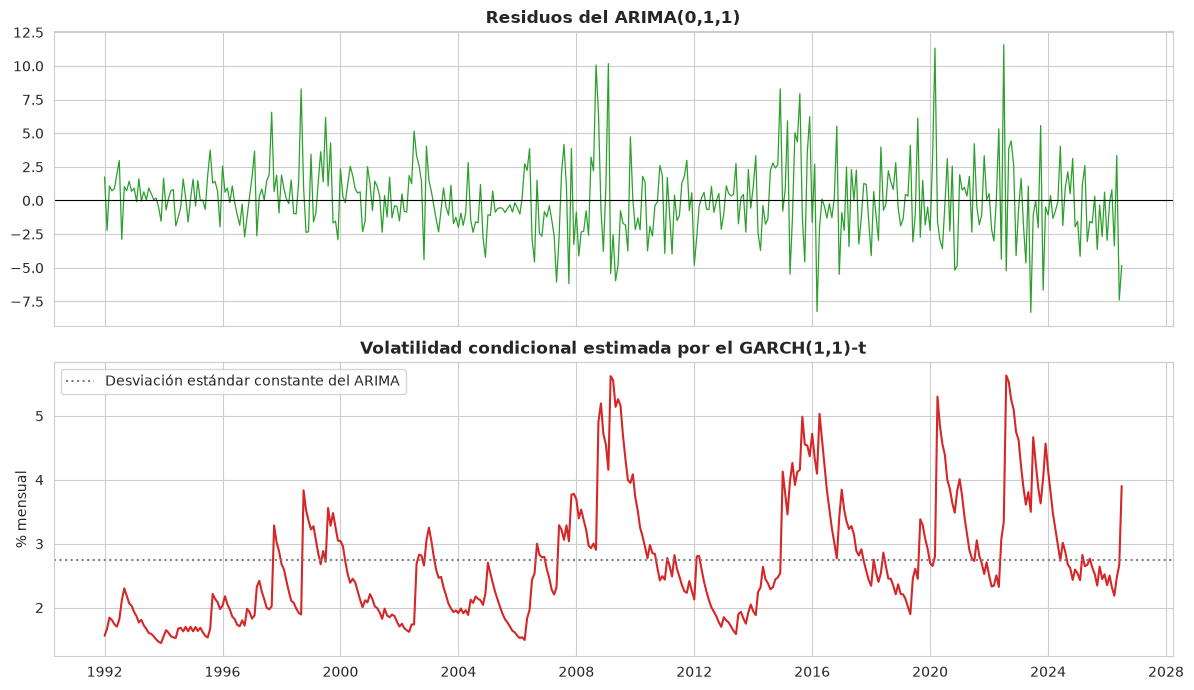

Ljung-Box(12) residuos estandarizados: p = 0.3360
Ljung-Box(12) residuos estandarizados al cuadrado: p = 0.8630
ARCH-LM(12) residuos estandarizados: p = 0.8835


In [ ]:
z = garch.std_resid
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(residuos.index, residuos.values, color=VERDE, linewidth=0.9)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("Residuos del ARIMA(0,1,1)")
axes[1].plot(garch.conditional_volatility.index, garch.conditional_volatility.values, color=ROJO)
axes[1].axhline(np.sqrt(modelo_media.params["sigma2"]), color="gray", linestyle=":", label="Desviación estándar constante del ARIMA")
axes[1].set_title("Volatilidad condicional estimada por el GARCH(1,1)-t")
axes[1].set_ylabel("% mensual")
axes[1].legend(loc="upper left")
plt.tight_layout()
guardar(fig, "13_volatilidad_garch.png")
plt.show()

print(f"Ljung-Box(12) residuos estandarizados: p = {acorr_ljungbox(z, lags=[12], return_df=True)['lb_pvalue'].iloc[0]:.4f}")
print(f"Ljung-Box(12) residuos estandarizados al cuadrado: p = {acorr_ljungbox(z ** 2, lags=[12], return_df=True)['lb_pvalue'].iloc[0]:.4f}")
print(f"ARCH-LM(12) residuos estandarizados: p = {het_arch(z, nlags=12)[1]:.4f}")

**Interpretación:** A partir de la gráfica se puede observar que la volatilidad condicional no es constante, sino que aumenta en los tramos donde los residuos presentan mayor amplitud, como se evidencia cerca de 2009, 2016, 2020 y 2022, y disminuye en los períodos de calma, comportamiento que coincide con el agrupamiento de volatilidad (Cont, 2001). Por otro lado, los residuos estandarizados ya no presentan dependencia ni en niveles ni al cuadrado, con p-valores de 0.3360 y 0.8630 en la prueba de Ljung-Box y de 0.8835 en la ARCH-LM, por lo que el GARCH(1,1) captura la heterocedasticidad condicional que el ARIMA dejaba sin modelar.

## 4.5 Modelo final

En conjunto, el modelo final de la TRM queda compuesto por el ARIMA(0,1,1) con constante para la media y el GARCH(1,1) con innovaciones t de Student para la varianza:

$$X_t = X_{t-1} + 0.3946 + \varepsilon_t + 0.3277\, \varepsilon_{t-1}, \qquad \varepsilon_t = \sigma_t z_t, \qquad \sigma_t^2 = 0.3084 + 0.1672\, \varepsilon_{t-1}^2 + 0.8108\, \sigma_{t-1}^2$$

con $z_t$ distribuida como una t de Student estandarizada de 6.30 grados de libertad. Esta especificación se encuentra en la función `modelo.ajustar_modelo` del paquete `trm`, que es la que utilizan el notebook 03 y el tablero del proyecto.

In [ ]:
# Verificación: la función del paquete reproduce la estimación de este notebook
final = modelo.ajustar_modelo(X)
print(pd.concat([final.media.params, final.garch.params]).round(4).to_string())

intercept    0.3946
ma.L1        0.3277
sigma2       7.5335
omega        0.3084
alpha[1]     0.1672
beta[1]      0.8108
nu           6.3029


---
# 5. Dificultades observadas durante el proceso

A lo largo del modelado se presentaron dificultades en cada una de las etapas, desde la preparación de los datos hasta el diagnóstico.

En primer lugar, durante la preparación de los datos se encontró que la serie contiene dos meses incompletos en sus extremos, los cuales no eran evidentes a partir del promedio mensual y solo se identificaron al contar los días disponibles por mes. Como se mostró en la sección 3.4, conservarlos no altera la estructura de media móvil, pero sí la significancia de la constante, lo que evidencia que la revisión de la calidad de los datos puede modificar los resultados de las etapas posteriores.

En segundo lugar, la dificultad principal no consistió en ajustar un modelo sino en elegir la frecuencia sobre la cual identificarlo, ya que con más de 12 000 observaciones diarias el umbral de significancia se estrecha tanto que autocorrelaciones de magnitud despreciable resultan significativas y la prueba de Ljung-Box rechaza por efecto del tamaño muestral. Además, durante la identificación la firma gráfica no discriminó entre AR(1) y MA(1), ya que con un único coeficiente significativo en el primer rezago ambas especificaciones producen patrones muy similares en la ACF y la PACF, por lo que fue necesario recurrir a los criterios de información, a la significancia de los parámetros y al argumento teórico sobre el mecanismo de construcción de la serie.

Por otra parte, trabajar con una serie mensual hacía necesario evaluar la posible presencia de un componente estacional con período 12, sin embargo, aplicar una diferenciación estacional sin verificar previamente su necesidad habría sobrediferenciado la serie, introduciendo una raíz unitaria en la parte de media móvil (Plosser & Schwert, 1977), por lo que fue necesario comprobar formalmente la ausencia de estacionalidad antes de fijar $D = 0$.

Adicionalmente, en la etapa de estimación los criterios de selección no coincidieron en todos los casos, ya que el menor AIC correspondió a un SARIMA con coeficientes estacionales redundantes, y en el caso de la constante el AIC y la prueba de razón de verosimilitud favorecían su inclusión, mientras que el BIC favorecía su exclusión. Teniendo esto en cuenta, la decisión requirió combinar los criterios de información con las pruebas de razón de verosimilitud y la significancia de los parámetros, en lugar de depender de un único criterio.

Finalmente, el GARCH se estimó en dos etapas, de modo que los residuos del ARIMA se tratan como si fueran observados y la incertidumbre de la estimación de la media no se incorpora en la ecuación de la varianza, limitación que conviene tener presente al interpretar los intervalos del notebook 03.

---
# 6. Síntesis

| Etapa | Resultado |
|---|---|
| **Serie de trabajo** | Promedio mensual de 416 meses completos (diciembre de 1991 a julio de 2026); frecuencia mensual para evitar que el tamaño muestral vuelva significativas autocorrelaciones despreciables |
| **Identificación** | Log-nivel integrado de orden 1 y sin estacionalidad: rezagos estacionales dentro del umbral, Kruskal-Wallis con p-valor de 0.1221 y síntomas de sobrediferenciación al imponer $D = 1$. Un único coeficiente significativo en el primer rezago, compatible con la hipótesis de agregación temporal |
| **Estimación** | ARIMA(0,1,1) con constante, con el menor BIC de la grilla y el menor AIC y BIC entre los modelos no estacionales. Términos estacionales no significativos en conjunto (p-valor de 0.0760) |
| **Diagnóstico** | Residuos sin autocorrelación según Ljung-Box, pero no normales y con efectos ARCH (p-valor de 0.0032), capturados por un GARCH(1,1) con innovaciones t |

El modelo describe adecuadamente la estructura de dependencia del log-retorno mensual de la TRM, ya que su media móvil de primer orden y la magnitud de su coeficiente concuerdan con la predicción planteada en la sección 2.2 a partir del efecto de agregación temporal (Working, 1960), de modo que la estructura identificada se explica por el método de cálculo del indicador y no por el comportamiento del mercado cambiario. Esta distinción es relevante, puesto que un modelo estadísticamente válido no implica por sí mismo una capacidad de pronóstico aprovechable, pregunta que se evalúa en el notebook 03 frente a la caminata aleatoria.

---
# Referencias

Akaike, H. (1974). A new look at the statistical model identification. *IEEE Transactions on Automatic Control, 19*(6), 716–723.

Banco de la República. (2018). *Circular Reglamentaria Externa DODM-146. Asunto 8: Metodología de cálculo de la tasa de cambio representativa del mercado*. https://www.banrep.gov.co/sites/default/files/reglamentacion/archivos/dodm146-25052018.pdf

Banco de la República. (2026). *Tasa Representativa del Mercado (TRM). Serie diaria 1991-2026* [Conjunto de datos]. Portal de Estadísticas Económicas. https://suameca.banrep.gov.co/estadisticas-economicas/

Bollerslev, T. (1986). Generalized autoregressive conditional heteroskedasticity. *Journal of Econometrics, 31*(3), 307–327.

Bollerslev, T. (1987). A conditionally heteroskedastic time series model for speculative prices and rates of return. *The Review of Economics and Statistics, 69*(3), 542–547.

Box, G. E. P., Jenkins, G. M., Reinsel, G. C., & Ljung, G. M. (2015). *Time series analysis: Forecasting and control* (5.ª ed.). Wiley.

Burnham, K. P., & Anderson, D. R. (2002). *Model selection and multimodel inference: A practical information-theoretic approach* (2.ª ed.). Springer.

Cont, R. (2001). Empirical properties of asset returns: Stylized facts and statistical issues. *Quantitative Finance, 1*(2), 223–236.

Dickey, D. A., & Fuller, W. A. (1979). Distribution of the estimators for autoregressive time series with a unit root. *Journal of the American Statistical Association, 74*(366), 427–431.

Engle, R. F. (1982). Autoregressive conditional heteroscedasticity with estimates of the variance of United Kingdom inflation. *Econometrica, 50*(4), 987–1007.

Fama, E. F. (1970). Efficient capital markets: A review of theory and empirical work. *The Journal of Finance, 25*(2), 383–417.

Kruskal, W. H., & Wallis, W. A. (1952). Use of ranks in one-criterion variance analysis. *Journal of the American Statistical Association, 47*(260), 583–621.

Kwiatkowski, D., Phillips, P. C. B., Schmidt, P., & Shin, Y. (1992). Testing the null hypothesis of stationarity against the alternative of a unit root: How sure are we that economic time series have a unit root? *Journal of Econometrics, 54*(1–3), 159–178.

Ljung, G. M., & Box, G. E. P. (1978). On a measure of lack of fit in time series models. *Biometrika, 65*(2), 297–303.

Mandelbrot, B. (1963). The variation of certain speculative prices. *The Journal of Business, 36*(4), 394–419.

McLeod, A. I., & Li, W. K. (1983). Diagnostic checking ARMA time series models using squared-residual autocorrelations. *Journal of Time Series Analysis, 4*(4), 269–273.

Plosser, C. I., & Schwert, G. W. (1977). Estimation of a non-invertible moving average process: The case of overdifferencing. *Journal of Econometrics, 6*(2), 199–224.

Schwarz, G. (1978). Estimating the dimension of a model. *The Annals of Statistics, 6*(2), 461–464.

Seabold, S., & Perktold, J. (2010). Statsmodels: Econometric and statistical modeling with Python. *Proceedings of the 9th Python in Science Conference*, 92–96.

Sheppard, K. (2025). *arch* (Versión 8.0.0) [Software]. https://github.com/bashtage/arch

Wilks, S. S. (1938). The large-sample distribution of the likelihood ratio for testing composite hypotheses. *The Annals of Mathematical Statistics, 9*(1), 60–62.

Working, H. (1960). Note on the correlation of first differences of averages in a random chain. *Econometrica, 28*(4), 916–918.